# Closing the FEM formats: NURBS, results files, time histories and refinement trees

Added in v16.12.0, the last halves of the FEM interchange formats:

- **MFEM** reads NURBS meshes and fields (evaluated to VTK Lagrange cells), Bernstein and serendipity spaces, and grid functions on non-conforming meshes.
- **Tecplot** reads binary `.plt` files back to Tecplot 7 (`#!TDV71`).
- **Patran** reads and writes loads and boundary conditions, and reads its `.nod`/`.els`/`.dis` result files.
- **Abaqus `.fil`** reads modes, energies, contact output and element matrices.
- **Radioss** gains a time-history reader, `radioss_th`, checked against a run of OpenRadioss itself.
- **Z88** reads the 16-node plate whole; **libMesh** writes refinement trees back; **Marc** follows `INCLUDE`, reads more element types and remeshing increments.
- **LS-DYNA** reads SPH particles and the `binout`; **OP2** reads complex and random tables; the **Ansys `.rst`** reader expands modal cyclic models.

Every mesh below comes from `tests/python/meshes/`.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None, lines=False):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4') or lines]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True, zoom=1.0):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(zoom)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## MFEM NURBS meshes

`mfem/nurbs/pipe-nurbs.mesh` is MFEM's quarter pipe, one NURBS patch of order 2 with rational weights on the arcs, with a field `u` on the NURBS space. Each knot span is evaluated, rational basis and all, to a Lagrange cell of the NURBS order (at order 2, `hexahedron27` and `quad9` on the boundary), so the arcs stay round. The values match MFEM's own evaluation to 3e-14.

[('hexahedron27', 8, 27), ('quad9', 24, 9)]


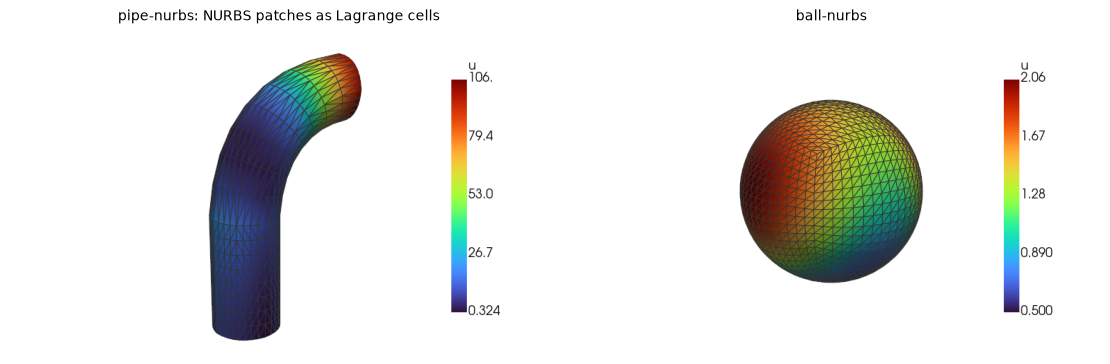

In [2]:
pipe = mp.mfem.read(path('mfem/nurbs', 'pipe-nurbs.mesh'), {'u': path('mfem/nurbs', 'pipe-nurbs.u.gf')})
print([(c.type, len(c.data), len(c.data[0])) for c in pipe.cells])
target = os.path.join(TMP, 'pipe.vtu')
mp.write(target, pipe)
ball = mp.mfem.read(path('mfem/nurbs', 'ball-nurbs.mesh'), {'u': path('mfem/nurbs', 'ball-nurbs.u.gf')})
mp.write(os.path.join(TMP, 'ball.vtu'), ball)
gallery([(curved(pv.read(target), 3), 'u', 'pipe-nurbs: NURBS patches as Lagrange cells', None),
         (curved(pv.read(os.path.join(TMP, 'ball.vtu')), 3), 'u', 'ball-nurbs', None)], ncols=2)

## Tecplot 7 binary files

`tecplot/visit/fluid.plt` comes from VisIt's Tecplot test data (BSD-3): a Tecplot 7 file (`#!TDV71`) holding one ordered IJK zone, read as hexahedra. Tecplot 7 lays out its zone records, its text and geometry records and its connectivity differently from later versions. The reader follows VisIt's reader, and both engines read the suite's 60 files identically.

b'#!TDV71 ' [('hexahedron', 880)] ['E', 'RHO-V']


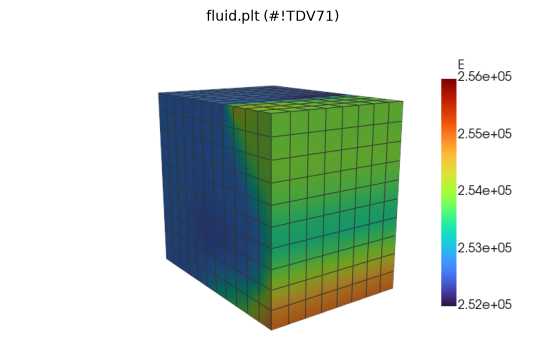

In [3]:
old = mp.read(path('tecplot/visit', 'fluid.plt'))
print(open(path('tecplot/visit', 'fluid.plt'), 'rb').read(8), [(c.type, len(c.data)) for c in old.cells], sorted(old.point_data))
gallery([(to_grid(old, point_data={'E': old.point_data['E']}), 'E', 'fluid.plt (#!TDV71)', None)], ncols=1, size=(760, 460))

## Patran result files and loads

`patran/real/warp3d_ssy.out` is WARP3D's Patran neutral file for a small-scale-yielding model, with its result files beside it. `.wnfr` and `.wefe` are text (nodal and element), and `.wnbd` and `.webs` are Fortran binary. Pass them to `mp.patran.read` by name. The neutral file's constraints (packet 08) come back as `patran:displacement:<set>`.

{'patran:displacement:1': (164, 6), 'wnbd00001': (164, 3), 'wnfr00001': (164, 3)}
{'patran:property': (40,), 'webs00001': (40, 26), 'wefe00001': (40, 22)}


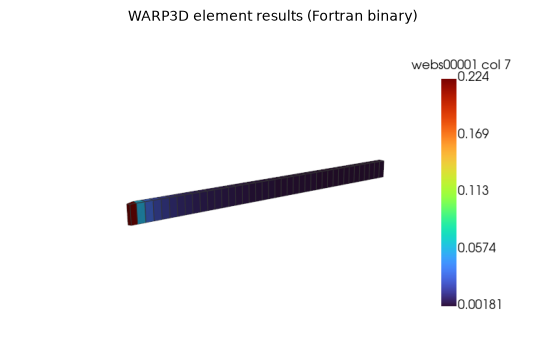

In [4]:
results = {k: path('patran/real', f'warp3d_ssy.{k}') for k in ('wnfr00001', 'wefe00001', 'wnbd00001', 'webs00001')}
ssy = mp.patran.read(path('patran/real', 'warp3d_ssy.out'), results)
print({k: v.shape for k, v in ssy.point_data.items()})
print({k: v[0].shape for k, v in ssy.cell_data.items()})
seqv = ssy.cell_data['webs00001'][0][:, 6]  # the binary element stresses' equivalent stress column
gallery([(to_grid(ssy, cell_data={'webs00001 col 7': [seqv]}), 'webs00001 col 7', 'WARP3D element results (Fortran binary)', None)],
        ncols=1, size=(760, 460))

## Abaqus `.fil` modes

`abaqus_fil/bertoldi/job-strip-angle-buckle-45.fil` is a real Abaqus 6.23 buckling run (MIT). Each mode is a step with its eigenvalue, and the buckling shapes are its displacement (drawn at 10 % of the strip's size).

eigenvalues: [2.10294, 2.10302]


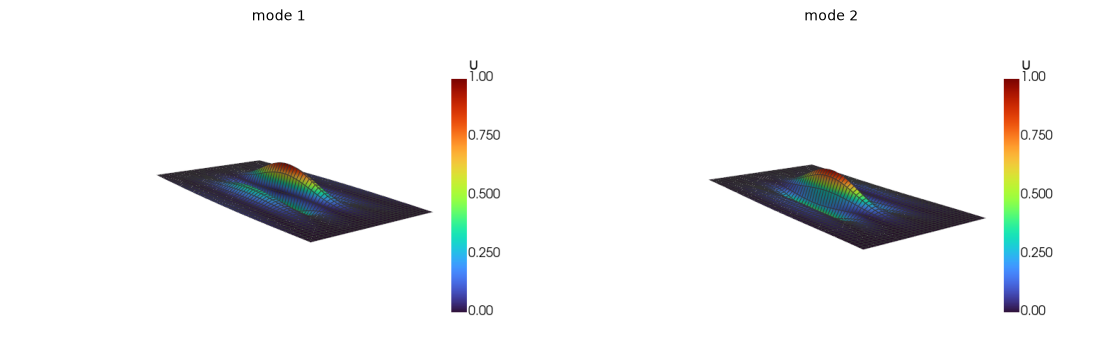

In [5]:
fil = path('abaqus_fil/bertoldi', 'job-strip-angle-buckle-45.fil')
modes = [mp.read(fil, time_step=k) for k in range(2)]
print('eigenvalues:', [round(float(m.field_data['abaqus:eigenvalue']), 5) for m in modes])
items = []
for k, m in enumerate(modes):
    u = m.point_data['U'][:, :3]
    extent = np.ptp(m.points, axis=0).max()
    shape = mp.Mesh(m.points + 0.1 * extent * u / np.abs(u).max(), m.cells)  # 10 % of the model's size
    items.append((to_grid(shape, point_data={'|U|': np.linalg.norm(u, axis=1)}), '|U|', f"mode {k + 1}", None))
gallery(items, ncols=2)

## Radioss time histories

`radioss_th/column` is a run of OpenRadioss itself: two steel bricks, one end held, the other pushed at 1 mm/ms. The time-history file `columnT01` has one output per 0.5 µs. Each output is a step with no points, and the global energies, part variables and TH-group arrays are field data. Every value matches OpenRadioss's own `th_to_csv`.

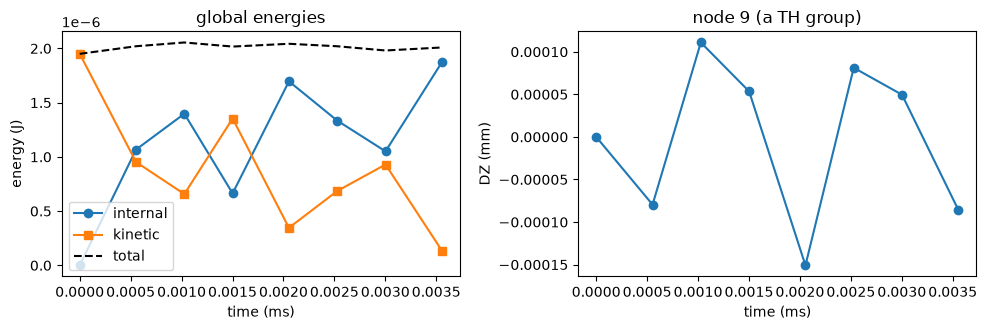

In [6]:
th = path('radioss_th/column', 'columnT01')
steps = [m for _, m in mp.read_sequence(th)]
t = [float(m.field_data['meshio:time'][0]) for m in steps]
ie = [float(m.field_data['radioss_th:global:internal_energy'][0]) for m in steps]
ke = [float(m.field_data['radioss_th:global:kinetic_energy'][0]) for m in steps]
top = [m.field_data['radioss_th:node:1'][1, 2] for m in steps]  # node 9, DZ
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.4))
a.plot(t, ie, 'o-', label='internal'); a.plot(t, ke, 's-', label='kinetic'); a.plot(t, np.add(ie, ke), 'k--', label='total')
a.set_xlabel('time (ms)'); a.set_ylabel('energy (J)'); a.legend(); a.set_title('global energies')
b.plot(t, top, 'o-'); b.set_xlabel('time (ms)'); b.set_ylabel('DZ (mm)'); b.set_title('node 9 (a TH group)')
plt.tight_layout(); plt.show()

## Z88 16-node plates and libMesh refinement trees

Z88's 16-node plate (type 19) now reads whole, as an order-3 Lagrange quad, and writes back. A libMesh mesh keeps its refinement tree as field data. `libmesh/tree_quad.xdr`, which libMesh refined itself into three levels, writes back with the same tree and its boundary sets on the level-0 elements.

[('VTK_LAGRANGE_QUADRILATERAL', (4, 16))]
tree rows: (24, 5) | active cells: 19
tree written back: True


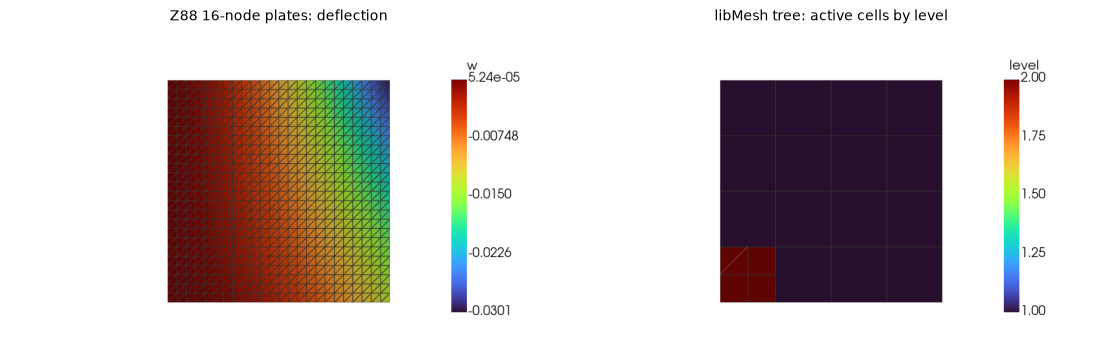

In [7]:
plate = mp.read(path('z88/plate19', 'z88i1.txt'))
print([(c.type, c.data.shape) for c in plate.cells])
mp.write(os.path.join(TMP, 'plate19.vtu'), mp.Mesh(plate.points, plate.cells, point_data={'w': plate.point_data['U'][:, 0]}))
tree = mp.read(path('libmesh', 'tree_quad.xdr'))
print('tree rows:', tree.field_data['libmesh:tree'].shape, '| active cells:', len(tree.cells[0].data))
back = os.path.join(TMP, 'tree.xda')
mp.write(back, tree)
print('tree written back:', np.array_equal(mp.read(back).field_data['libmesh:tree'], tree.field_data['libmesh:tree']))
gallery([(curved(pv.read(os.path.join(TMP, 'plate19.vtu')), 3), 'w', 'Z88 16-node plates: deflection', None),
         (to_grid(tree, cell_data={'level': tree.cell_data['libmesh:level']}), 'level', 'libMesh tree: active cells by level', None)],
        ncols=2, view=(0, 0, 1))

## Marc: `INCLUDE`, more element types and remeshing

`marc/include_main.dat` `INCLUDE`s its coordinates, which `INCLUDE` its sets. It holds a Herrmann brick and quad, a composite brick and a rebar line. `marc/remesh.t19`'s second increment remeshes, so that step has its own mesh.

[('hexahedron', 2), ('line3', 1), ('quad', 1)] ['marc:edge_set:rim', 'marc:face_set:top']


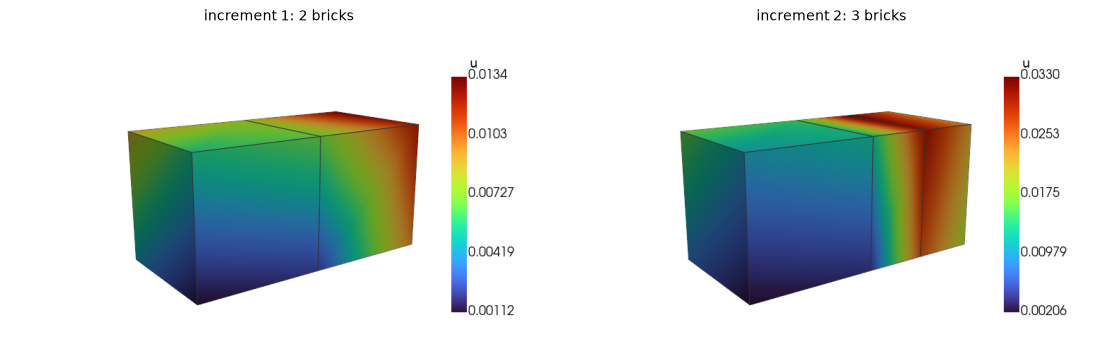

In [8]:
deck = mp.read(path('marc', 'include_main.dat'))
print([(c.type, len(c.data)) for c in deck.cells], sorted(deck.field_data))
before = mp.read(path('marc', 'remesh.t19'), time_step=0)
after = mp.read(path('marc', 'remesh.t19'), time_step=1)
gallery([(to_grid(m, point_data={'|u|': np.linalg.norm(m.point_data['Displacement'], axis=1)}), '|u|',
          f"increment {k + 1}: {len(m.cells[0].data)} bricks", None) for k, m in enumerate((before, after))], ncols=2)

## LS-DYNA SPH and binout, Nastran complex results, Ansys modal cyclic models

- `lsdyna_d3plot/dyna/bird_strike` is a bird strike from Ansys' example data: 701 SPH particles, read as `vertex` cells, hit composite shells.
- `nastran_op2/modes_complex_elements.op2` gives complex modes as `_real`/`_imag` pairs.
- `ansys/rst/cyclic_v182.rst` is a cyclic sector; `ansys_rst_cyclic` expands it to the full rotor.

[('triangle', 48), ('quad', 2256), ('vertex', 701)]
complex mode: ['EIGENVECTOR_ROT_imag', 'EIGENVECTOR_ROT_real', 'EIGENVECTOR_imag', 'EIGENVECTOR_real', 'SPC_FORCE_ROT_imag', 'SPC_FORCE_ROT_real', 'SPC_FORCE_imag', 'SPC_FORCE_real']
sector cells: 210 -> rotor cells: 1575


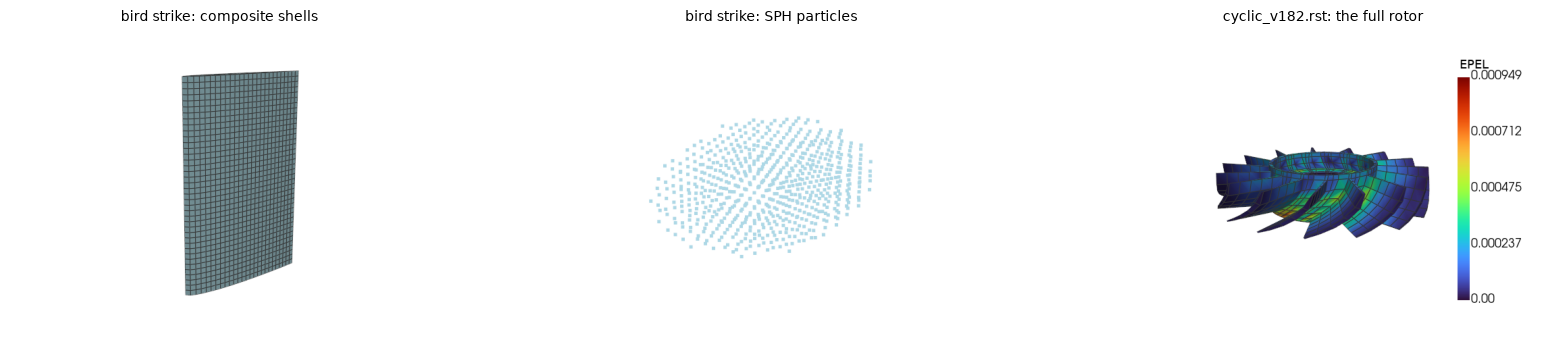

In [9]:
bird = mp.read(path('lsdyna_d3plot/dyna/bird_strike', 'd3plot'), time_step=-1)
print([(c.type, len(c.data)) for c in bird.cells])
modes = mp.read(path('nastran_op2', 'modes_complex_elements.op2'), time_step=-1)
print('complex mode:', sorted(k for k in modes.point_data if k.endswith(('_real', '_imag'))))
rotor = mp.read(path('ansys/rst', 'cyclic_v182.rst'), file_format='ansys_rst_cyclic')
sector = mp.read(path('ansys/rst', 'cyclic_v182.rst'))
print('sector cells:', sum(len(c.data) for c in sector.cells), '-> rotor cells:', sum(len(c.data) for c in rotor.cells))
sph = [c for c in bird.cells if c.type == 'vertex'][0].data.ravel()
shells = mp.Mesh(bird.points, [c for c in bird.cells if c.type != 'vertex'])
cloud = pv.PolyData(np.asarray(bird.points)[sph])
key = next(k for k in rotor.point_data if np.asarray(rotor.point_data[k]).ndim == 2)
gallery([(to_grid(shells), None, 'bird strike: composite shells', None),
         (cloud, None, 'bird strike: SPH particles', None),
         (to_grid(rotor, point_data={'|' + key + '|': np.linalg.norm(rotor.point_data[key][:, :3], axis=1)}),
          '|' + key + '|', 'cyclic_v182.rst: the full rotor', None)], ncols=3, size=(620, 460))